In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_subsys_masks(channel_names):    
    # Create boolean masks for each subsystem
    subsys_counts = {}
    subsys_masks = {}
    n = len(channel_names)
    for i, name in enumerate(channel_names):
        key = name[3:6]

        subsys_counts[key] = subsys_counts.get(key, 0) + 1

        if key not in subsys_masks:
            subsys_masks[key] = np.zeros(n, dtype=bool)
        subsys_masks[key][i] = True
    return subsys_masks
gt = pd.read_parquet('../data/GW/test_stand_CTWS.parquet')
channel_names = list(gt.keys())
subsys_masks = get_subsys_masks(channel_names)

In [2]:
values = torch.load('values/GWIMC_100s_k15.pt', map_location='cpu')
preds = values[0]
ground_truth = values[1]

gtSUB = gt.iloc[:,subsys_masks['IMC']] # Rest: subsys_masks['TCS'] + subsys_masks['PSL'] + subsys_masks['OMC'] + subsys_masks['CAL'] + subsys_masks['ALS'] + subsys_masks['LSC']

In [3]:
gt_onesample = gt.iloc[:2048,:]
gt_use = gt_onesample.drop(columns=['attack'])
gt_use

,L1:ALS-C_TRX_A_LF_OUT_DQ,L1:ALS-C_TRY_A_LF_OUT_DQ,L1:ASC-AS_A_DC_PIT_OUT_DQ,L1:ASC-AS_A_DC_YAW_OUT_DQ,L1:ASC-AS_A_RF36_I_PIT_OUT_DQ,L1:ASC-AS_A_RF36_I_YAW_OUT_DQ,L1:ASC-AS_A_RF36_Q_PIT_OUT_DQ,L1:ASC-AS_A_RF36_Q_YAW_OUT_DQ,L1:ASC-AS_A_RF72_I_PIT_OUT_DQ,L1:ASC-AS_A_RF72_I_YAW_OUT_DQ,...,L1:SUS-ZM1_M1_DAMP_L_IN1_DQ,L1:SUS-ZM1_M1_DAMP_P_IN1_DQ,L1:SUS-ZM1_M1_DAMP_Y_IN1_DQ,L1:SUS-ZM2_M1_DAMP_L_IN1_DQ,L1:SUS-ZM2_M1_DAMP_P_IN1_DQ,L1:SUS-ZM2_M1_DAMP_Y_IN1_DQ,L1:TCS-ITMX_CO2_ISS_IN_AC_OUT_DQ,L1:TCS-ITMX_CO2_ISS_OUT_AC_OUT_DQ,L1:TCS-ITMY_CO2_ISS_IN_AC_OUT_DQ,L1:TCS-ITMY_CO2_ISS_OUT_AC_OUT_DQ
0,-0.973244,-1.419899,0.344868,-0.460956,0.325794,-0.194200,-2.460416,0.030768,0.308938,-0.331222,...,1.938287,-0.577254,-0.858816,1.308820,-0.703079,2.224119,0.848798,0.491315,2.527110,-0.072661
1,-0.540293,-1.460611,0.368876,-0.468434,0.302441,-0.181915,-2.459163,-0.005853,0.335368,-0.316481,...,1.938228,-0.579592,-0.857679,1.308759,-0.701614,2.225296,0.777179,-0.523696,1.711004,-0.489551
2,-0.046018,-1.267206,0.393174,-0.476516,0.278977,-0.169137,-2.458288,-0.043046,0.364372,-0.297527,...,1.938374,-0.579671,-0.856933,1.308704,-0.700755,2.226560,0.479603,-0.099225,1.105346,-0.972293
3,-0.741952,-1.627781,0.418116,-0.485248,0.255587,-0.155548,-2.457745,-0.081083,0.392302,-0.280305,...,1.938292,-0.579666,-0.856253,1.308881,-0.699655,2.227588,-0.018276,1.150476,1.552352,-0.863621
4,-0.165670,-1.551489,0.442749,-0.494225,0.232307,-0.141948,-2.457492,-0.119831,0.419732,-0.265571,...,1.938522,-0.580432,-0.855124,1.308685,-0.698556,2.228334,0.864739,0.403676,1.475446,-0.149459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,-0.623039,-1.541455,0.111806,-1.770874,0.750729,0.894431,0.574813,-0.634148,-0.169386,-2.248053,...,1.938634,-2.203901,-0.494141,1.324400,0.554105,2.029142,0.430591,0.178339,0.590799,0.415349
2044,-0.837452,-1.157241,0.114237,-1.765044,0.750742,0.901560,0.588390,-0.640400,-0.172454,-2.261039,...,1.938695,-2.202320,-0.494322,1.324530,0.554442,2.026704,0.145904,0.905099,0.894427,0.168693
2045,-0.242411,-1.567027,0.116266,-1.758633,0.750448,0.908133,0.602990,-0.647075,-0.174982,-2.270782,...,1.938551,-2.202361,-0.494530,1.324361,0.554624,2.024909,-0.665715,-0.341584,1.475531,0.125609
2046,-0.355232,-1.383651,0.118204,-1.751332,0.750229,0.914816,0.617254,-0.654327,-0.177023,-2.277659,...,1.938560,-2.201661,-0.493824,1.324485,0.555074,2.025822,0.980824,-0.011166,1.084097,0.365799


In [4]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Assume your DataFrame is df of shape (1648, 781)
results = {}

# Choose max lag; a common choice is 10-20
max_lag = 20

for col in gt_use.columns:
    # Ljung-Box returns an array of p-values for each lag
    lb_test = acorr_ljungbox(gt_use[col], lags=max_lag, return_df=True)
    # We'll take the max lag p-value
    p_value = lb_test['lb_pvalue'].iloc[-1]
    results[col] = p_value

# Convert to a DataFrame for easy inspection
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['p_value'])

# A typical threshold: p > 0.05 → cannot reject white noise
results_df['is_white_noise'] = results_df['p_value'] > 0.05

j = 0
for i in (results_df['is_white_noise'].values):
    j += i
print(j)

# So this says 0 of the 781 timeseries statistically can not be rejected as white noise

/data/gravwav/mvuden/miniconda3/envs/GNN_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


0


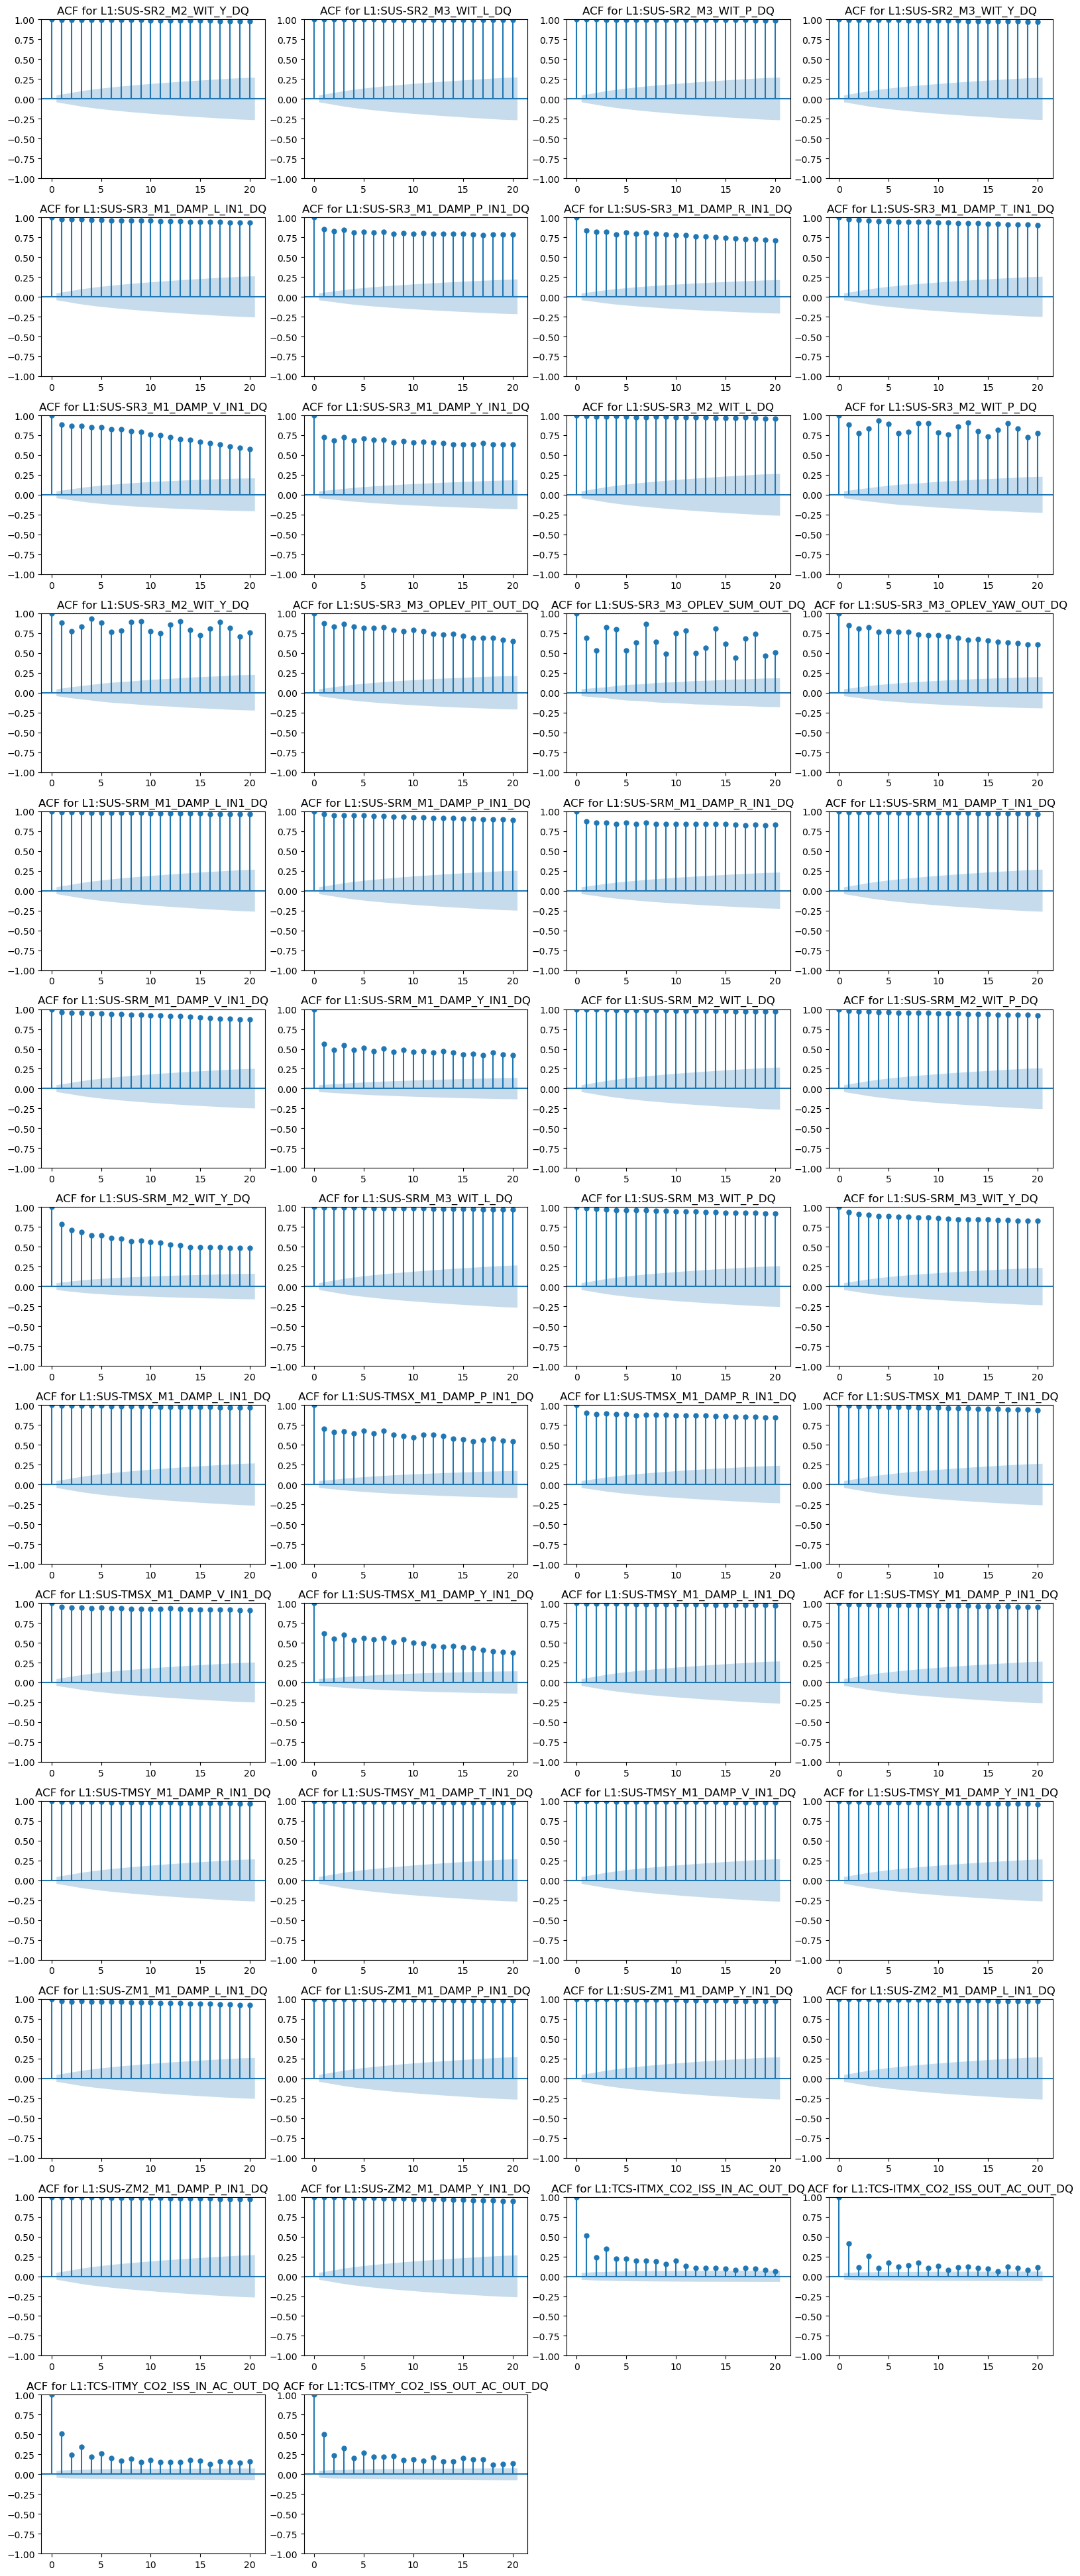

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
import math

# Columns to plot
cols_to_plot = gt_use.columns[-50:]  # change this slice as needed

# Layout: 4 plots per row
n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(cols_to_plot):
    plot_acf(gt_use[col], lags=20, ax=axes[i])
    axes[i].set_title(f'ACF for {col}')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

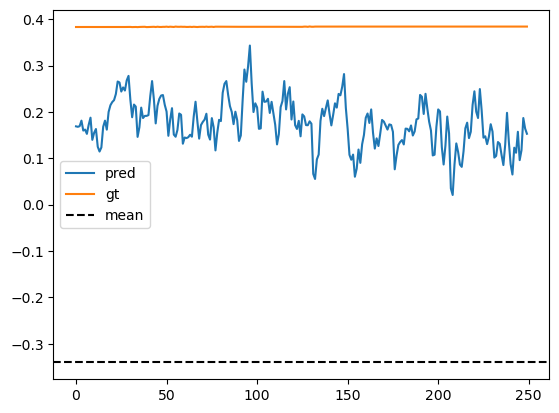

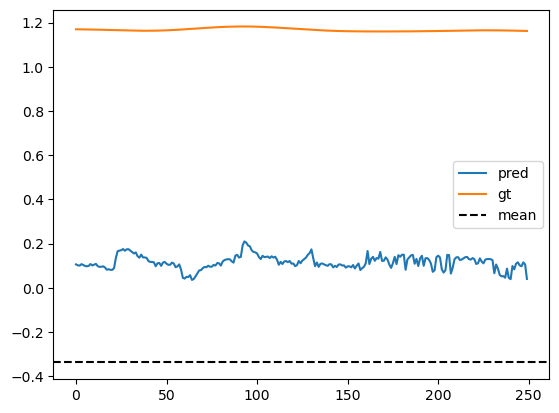

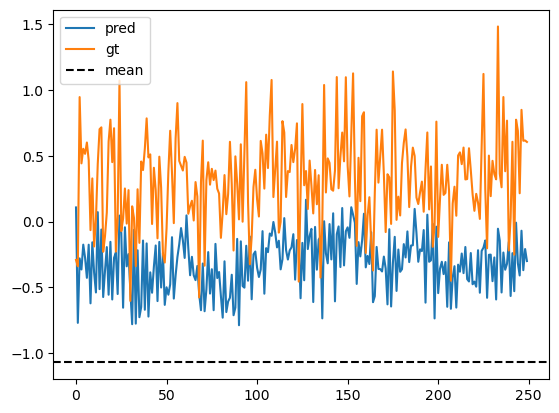

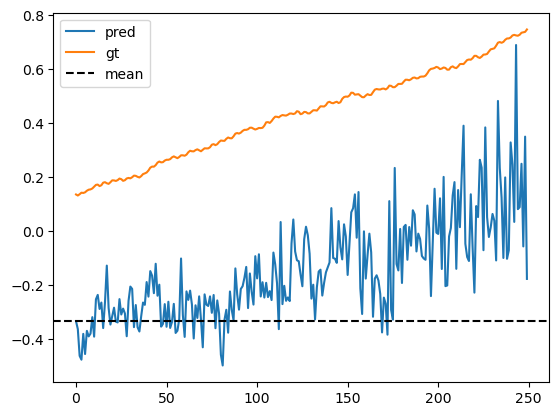

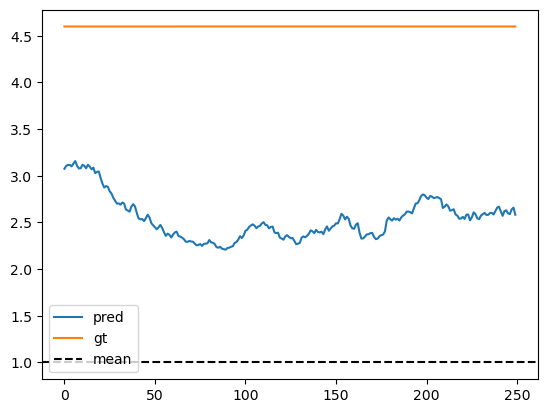

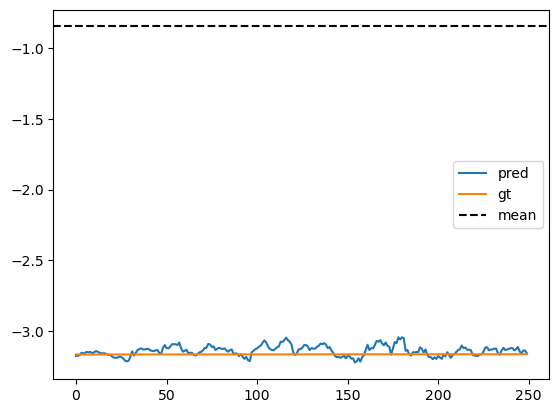

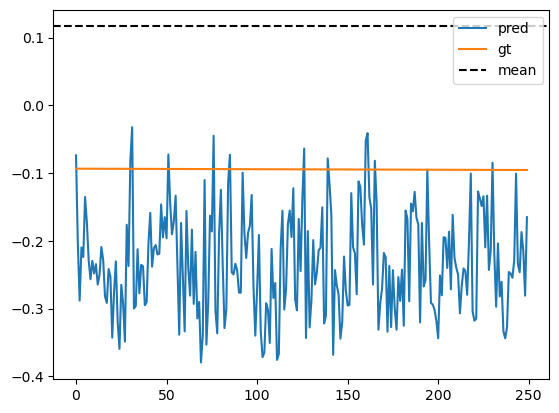

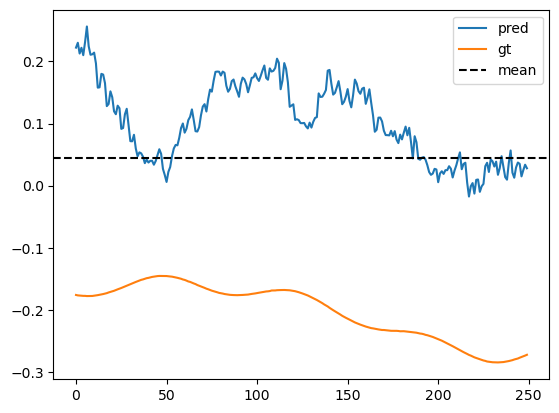

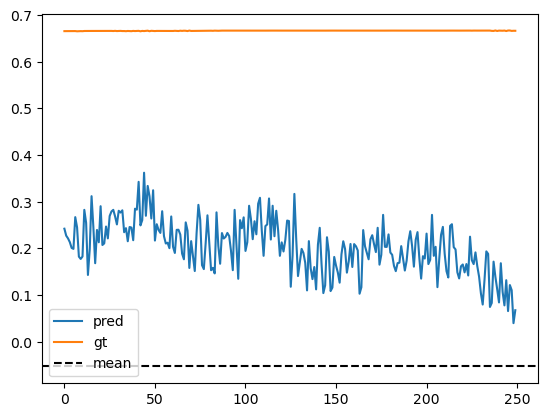

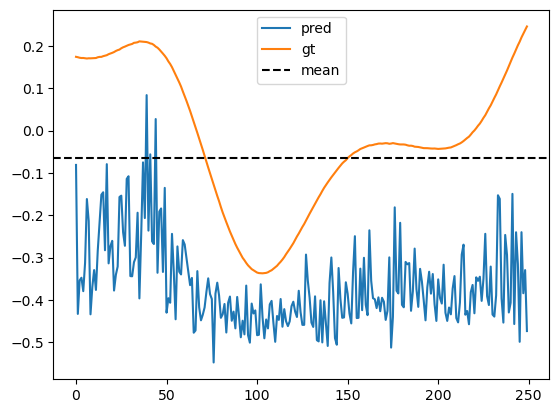

In [6]:

for id in range(10,20):
    mean = torch.mean(ground_truth[:,id].cpu())
    plt.plot(preds[3000:3250,id].cpu(), label = 'pred')
    plt.plot(ground_truth[3000:3250,id].cpu(), label = 'gt')
    plt.axhline(y=mean, linestyle='--', label='mean', color='black')
    plt.legend()
    plt.show()

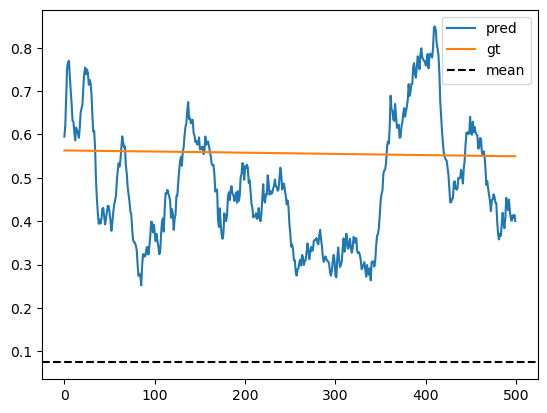

In [7]:
id = 20
mean = torch.mean(ground_truth[:,id].cpu())
plt.plot(preds[120000:120500,id].cpu(), label = 'pred')
plt.plot(ground_truth[120000:120500,id].cpu(), label = 'gt')
plt.axhline(y=mean, linestyle='--', label='mean', color='black')
plt.legend()
plt.show()

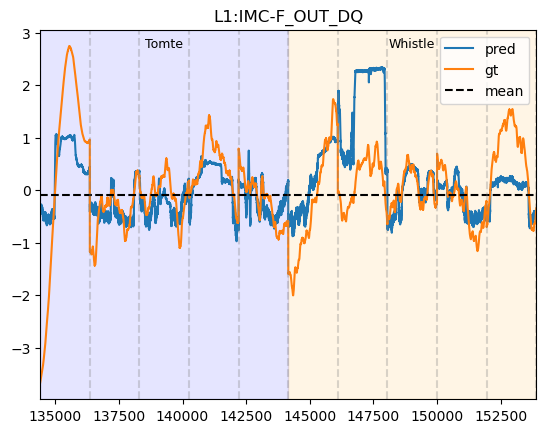

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

id = 8
mean = torch.mean(ground_truth[:, id].cpu()).item()
segment_len = ground_truth.shape[0]/4

step_size = int(segment_len / 37)
data_middle = int(2*segment_len)
show_len = int(1948*5)
show_step_lines = True

if data_middle == None:
    show_step_lines = False
# --- convert to numpy ---
pred_vals = preds[:, id].detach().cpu().numpy()
gt_vals = ground_truth[:, id].detach().cpu().numpy()

# --- slicing logic ---
if data_middle is None:
    x = np.arange(len(pred_vals))
    pred_plot = pred_vals.copy()
    gt_plot = gt_vals.copy()
else:
    start = data_middle - show_len
    end = data_middle + show_len

    x = np.arange(start, end)
    pred_plot = pred_vals[start:end].copy()
    gt_plot = gt_vals[start:end].copy()

# --- insert NaNs INSIDE THE VIEW ONLY ---
#for i in range(step_size, len(pred_plot), step_size):
#    pred_plot[i] = np.nan
#    gt_plot[i] = np.nan

plt.figure()

plt.plot(x, pred_plot, label="pred")
plt.plot(x, gt_plot, label="gt")

plt.axhline(y=mean, linestyle="--", label="mean", color="black")

# --- segments ---
segments = [
    ("Normal", 0, segment_len, "green"),
    ("Tomte", segment_len, 2 * segment_len, "blue"),
    ("Whistle", 2 * segment_len, 3 * segment_len, "orange"),
    ("Scat", 3 * segment_len, 4 * segment_len, "red"),
]

if data_middle is not None:
    plt.xlim(start, end)

x_min, x_max = plt.xlim()

for label, seg_start, seg_end, color in segments:
    vis_start = max(seg_start, x_min)
    vis_end = min(seg_end, x_max)

    if vis_start < vis_end:
        plt.axvspan(vis_start, vis_end, alpha=0.1, color=color)

        plt.text((vis_start + vis_end) / 2,
                 plt.ylim()[1] * 0.95,
                 label,
                 ha="center",
                 va="top",
                 fontsize=9)

# --- step lines ---
if show_step_lines:
    start_line = (int(x_min) // step_size) * step_size

    for xi in range(start_line, int(x_max) + step_size, step_size):
        if x_min <= xi <= x_max:
            plt.axvline(x=xi, color="gray", linestyle="--", alpha=0.3)

plt.title(gtSUB.columns[id])
plt.legend()
plt.show()

In [72]:
print(gtSUB.columns[20:24])

Index(['L1:SUS-ETMX_L3_OPLEV_YAW_OUT_DQ', 'L1:SUS-ETMX_M0_DAMP_L_IN1_DQ',
       'L1:SUS-ETMX_M0_DAMP_P_IN1_DQ', 'L1:SUS-ETMX_M0_DAMP_R_IN1_DQ'],
      dtype='object')


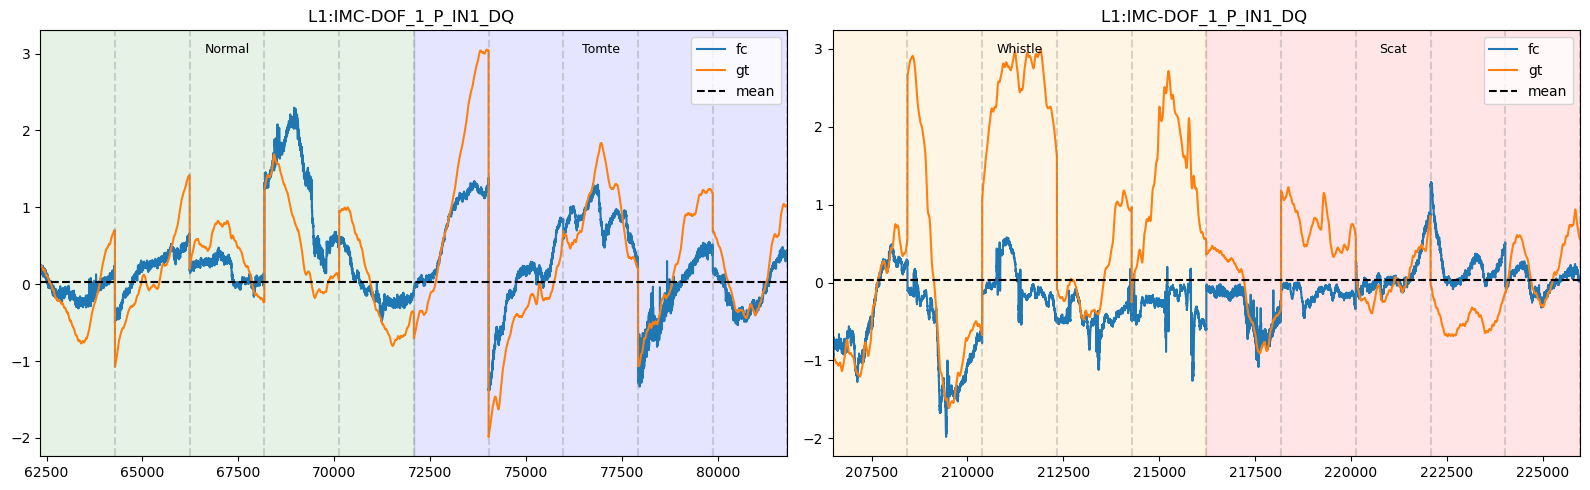

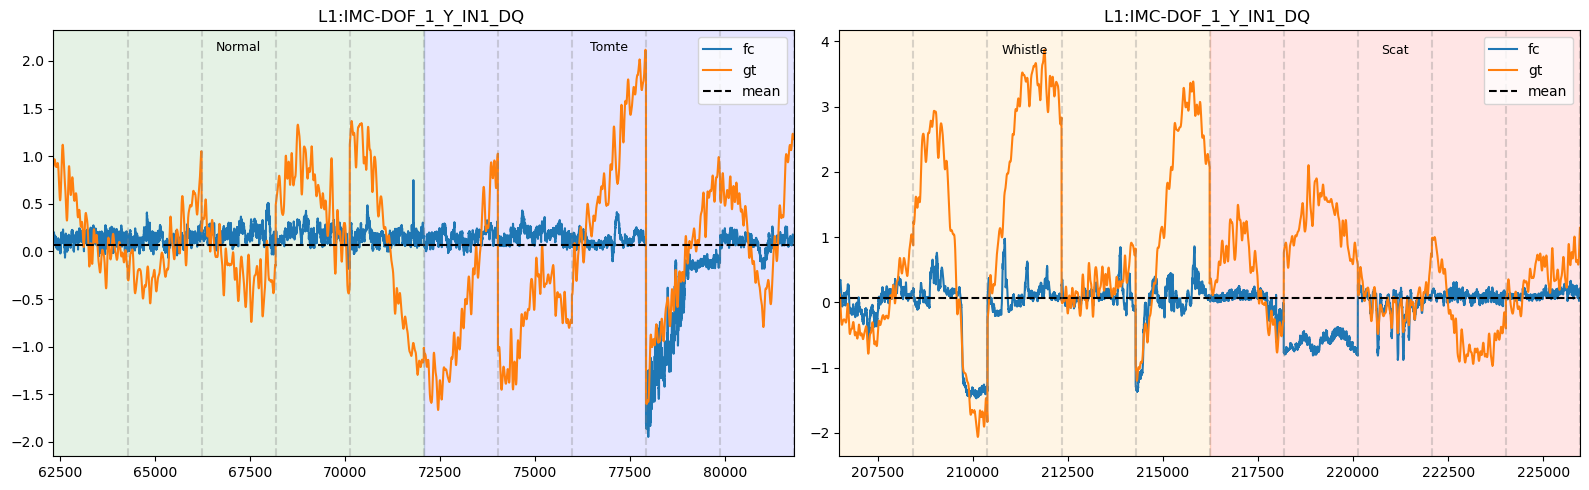

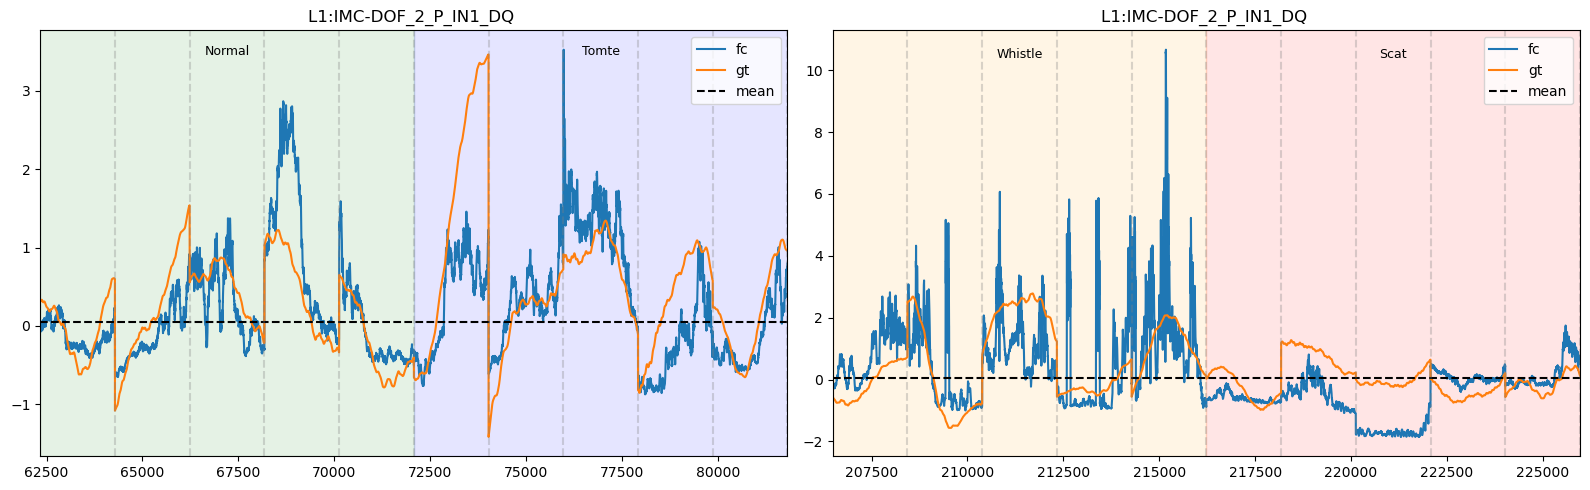

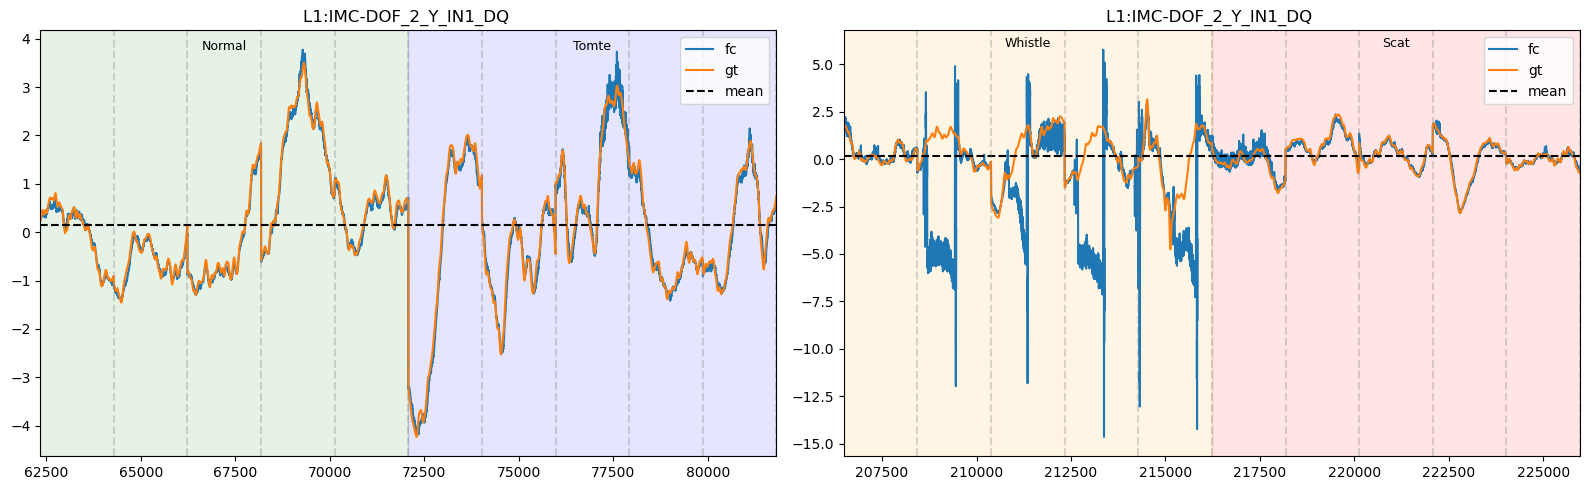

In [92]:
for id in range(0, 4):

    mean = torch.mean(ground_truth[:, id].cpu()).item()
    segment_len = ground_truth.shape[0] / 4

    step_size = int(segment_len / 37)
    show_len = int(1948 * 5)
    show_step_lines = True

    # --- convert to numpy ---
    pred_vals = preds[:, id].detach().cpu().numpy()
    gt_vals = ground_truth[:, id].detach().cpu().numpy()

    # --- segments ---
    segments = [
        ("Normal", 0, segment_len, "green"),
        ("Tomte", segment_len, 2 * segment_len, "blue"),
        ("Whistle", 2 * segment_len, 3 * segment_len, "orange"),
        ("Scat", 3 * segment_len, 4 * segment_len, "red"),
    ]

    # -------------------------------------------------
    # helper function
    # -------------------------------------------------
    def draw_plot(ax, data_middle, show_len, id, title_suffix=""):

        start = int(data_middle - show_len)
        end = int(data_middle + show_len)

        x = np.arange(start, end)

        pred_plot = pred_vals[start:end].copy()
        gt_plot = gt_vals[start:end].copy()

        ax.plot(x, pred_plot, label="fc")
        ax.plot(x, gt_plot, label="gt")

        ax.axhline(y=mean, linestyle="--", color="black", label="mean")

        ax.set_xlim(start, end)

        x_min, x_max = ax.get_xlim()

        # --- segment coloring ---
        for label, seg_start, seg_end, color in segments:

            vis_start = max(seg_start, x_min)
            vis_end = min(seg_end, x_max)

            if vis_start < vis_end:
                ax.axvspan(vis_start, vis_end, alpha=0.1, color=color)

                ax.text(
                    (vis_start + vis_end) / 2,
                    ax.get_ylim()[1] * 0.95,
                    label,
                    ha="center",
                    va="top",
                    fontsize=9
                )

        # --- step lines ---
        if show_step_lines:

            start_line = (int(x_min) // step_size) * step_size

            for xi in range(start_line, int(x_max) + step_size, step_size):

                if x_min <= xi <= x_max:
                    ax.axvline(
                        x=xi,
                        color="gray",
                        linestyle="--",
                        alpha=0.3
                    )

        ax.set_title(f"{gtSUB.columns[id]} {title_suffix}")
        ax.legend()

    # -------------------------------------------------
    # create side-by-side plots
    # -------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    draw_plot(
        axes[0],
        data_middle=int(1 * segment_len),
        show_len=show_len,
        id=id
    )

    draw_plot(
        axes[1],
        data_middle=int(3 * segment_len),
        show_len=show_len,
        id=id
    )

    plt.tight_layout()
    plt.show()

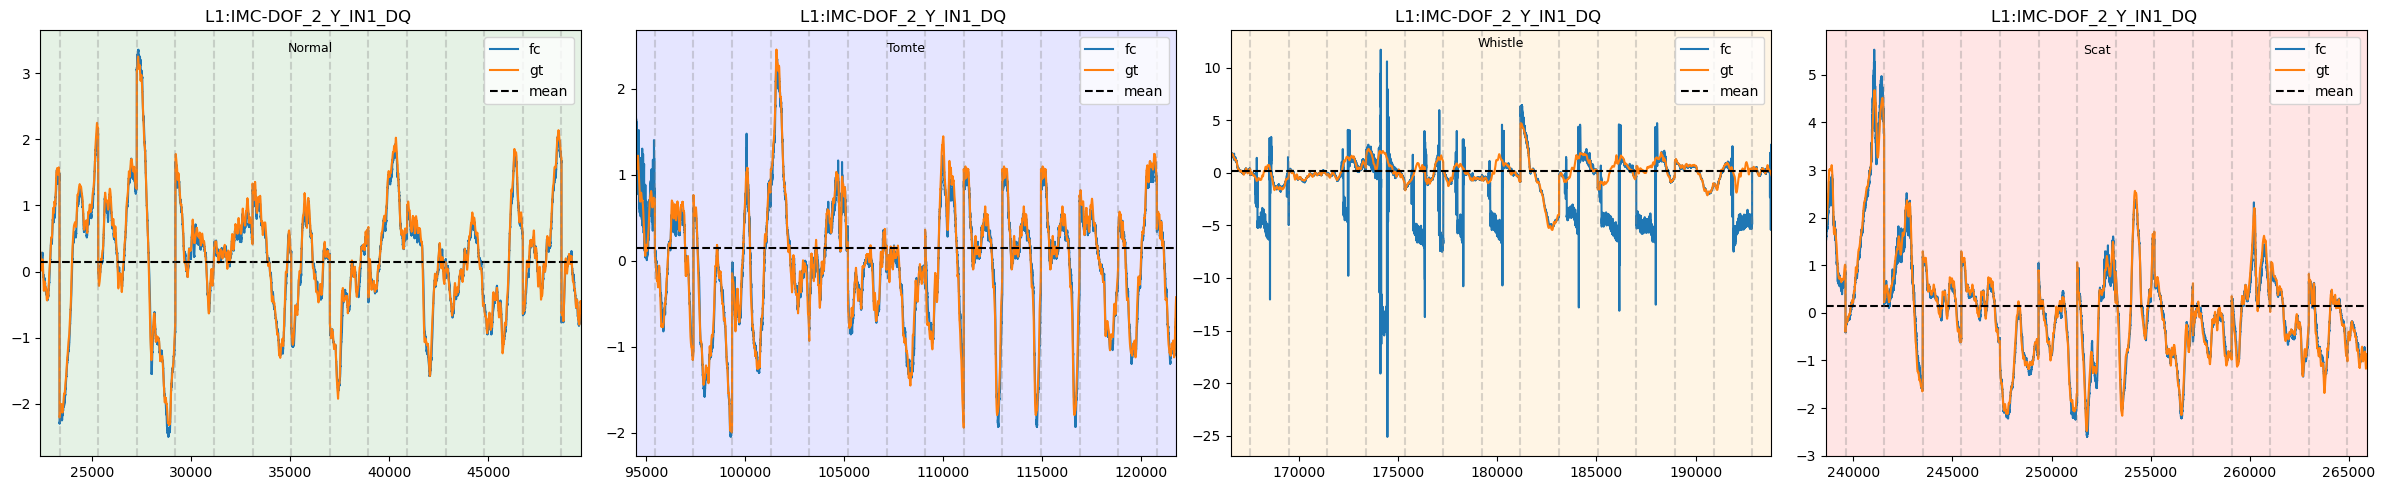

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
data_middles = [
    0.5 * segment_len,
    1.5 * segment_len,
    2.5 * segment_len,
    3.5 * segment_len,
]
titles = [
    "Normal",
    "Tomte",
    "Whistle",
    "Scat",
]
for ax, dm, title in zip(axes, data_middles, titles):
    draw_plot(
        ax,
        data_middle=int(dm),
        show_len = int(1948*7),
        id = 3
    )

plt.tight_layout()
plt.show()

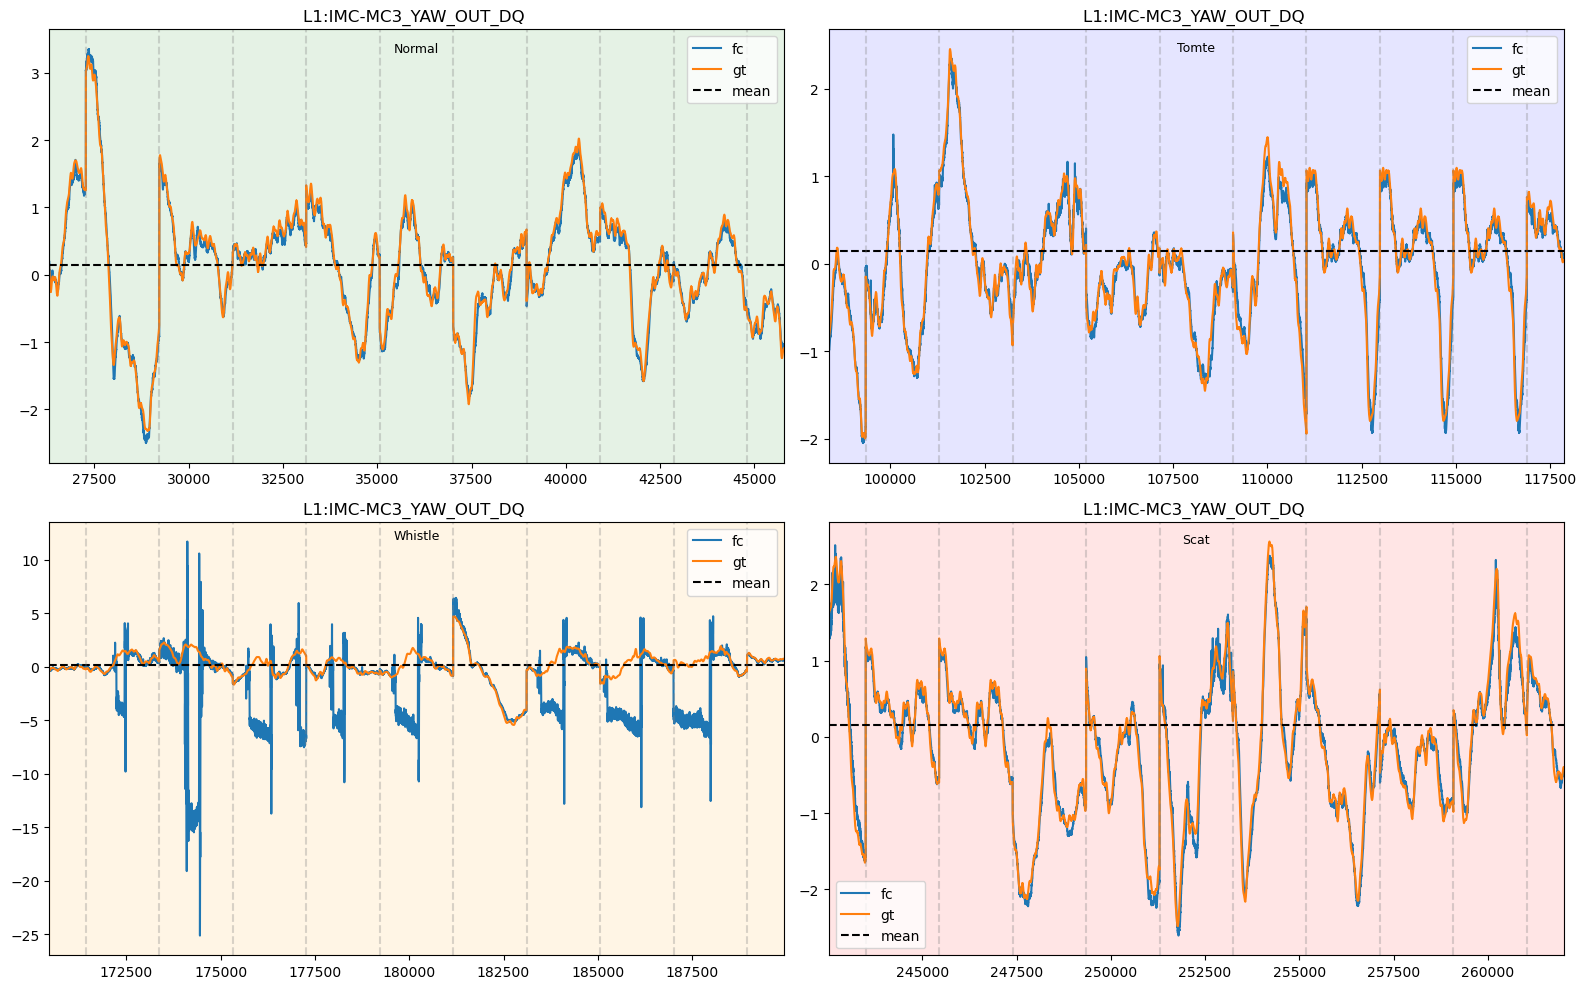

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

data_middles = [
    0.5 * segment_len,
    1.5 * segment_len,
    2.5 * segment_len,
    3.5 * segment_len,
]

titles = [
    "Normal",
    "Tomte",
    "Whistle",
    "Scat",
]

for ax, dm, title in zip(axes, data_middles, titles):

    draw_plot(
        ax,
        data_middle=int(dm),
        show_len=show_len,
        id = 22
    )

plt.tight_layout()
plt.show()

In [137]:
ground_truth.cpu().shape[0]/4*3

216228.0

In [126]:
22*1948

42856

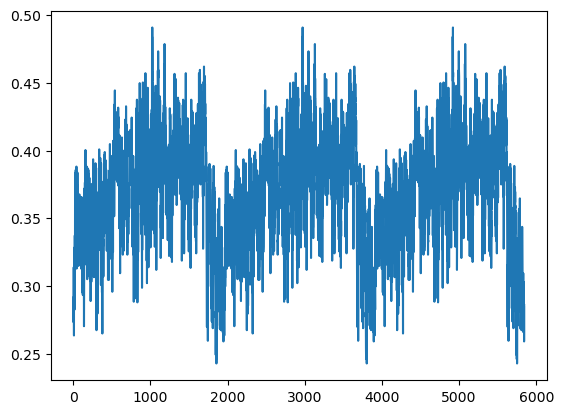

In [128]:
temp = preds.cpu()[72076:144152,22]
plt.plot(temp[38960:44804])

In [133]:
print(np.all(np.array(temp[38960:40908]) == np.array(temp[40908:42856])))

True


In [135]:
def detect_dupes(x):
    # -------------------------------------------------
    # reshape to [N_samples, 1948]
    # -------------------------------------------------
    N = x.numel() // 1948
    x = x.view(N, 1948)

    # -------------------------------------------------
    # find unique rows + grouping
    # -------------------------------------------------
    unique_rows, inverse_indices, counts = torch.unique(
        x,
        dim=0,
        return_inverse=True,
        return_counts=True
    )

    # -------------------------------------------------
    # collect duplicate groups
    # -------------------------------------------------
    duplicate_groups = []

    for i in range(len(counts)):
        if counts[i] > 1:
            idxs = (inverse_indices == i).nonzero(as_tuple=True)[0]
            duplicate_groups.append(idxs)

    # -------------------------------------------------
    # print results
    # -------------------------------------------------
    print(f"Total samples: {N}")
    print(f"Number of unique signals: {len(unique_rows)}")
    print(f"Number of duplicate groups: {len(duplicate_groups)}\n")

    for g in duplicate_groups:
        print("Duplicate indices:", g.tolist())

In [142]:
idx = 10

print('\nClean')
detect_dupes(x = ground_truth[:72076,10].cpu())
print('Tomte')
detect_dupes(x = ground_truth[72076:144152,10].cpu())
print('\nWhistle')
detect_dupes(x = ground_truth[144152:216228,10].cpu())
print('\nScattered Light')
detect_dupes(x = ground_truth[216228:,10].cpu())



Clean
Total samples: 37
Number of unique signals: 37
Number of duplicate groups: 0

Tomte
Total samples: 37
Number of unique signals: 33
Number of duplicate groups: 3

Duplicate indices: [24, 25]
Duplicate indices: [20, 21, 22]
Duplicate indices: [28, 29]

Whistle
Total samples: 37
Number of unique signals: 35
Number of duplicate groups: 2

Duplicate indices: [30, 31]
Duplicate indices: [0, 1]

Scattered Light
Total samples: 37
Number of unique signals: 36
Number of duplicate groups: 1

Duplicate indices: [14, 15]
